## Machine Learning Assignment (Regression)
# Medical Cost Personal Dataset

# Part 1 — Data Understanding

Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option('display.max_columns', None)

Load Dataset

In [11]:
df = pd.read_csv(r"C:\Users\saba\Downloads\archive (2)\insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Display First Five Records

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Display Last Five Records

In [5]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


Understand the dataset

Display Shape

In [12]:
df.shape

(1338, 7)

Display Column Names

In [13]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Display Data Types

In [15]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Dataset Information

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Statistical Summary

In [18]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [19]:
df.describe(include='object') # For categorical columns

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [20]:
df.describe(include='all') # Or everything together

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


Number of Rows

In [21]:
print("Number of Rows:", df.shape[0])

Number of Rows: 1338


Number of Columns

In [22]:
print("Number of Columns:", df.shape[1])

Number of Columns: 7


Number of Numerical Features

In [23]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns

print("Numerical Features:")
print(numerical_features)

print("Total Numerical Features:", len(numerical_features))

Numerical Features:
Index(['age', 'bmi', 'children', 'charges'], dtype='object')
Total Numerical Features: 4


Number of Categorical Features

In [24]:
categorical_features = df.select_dtypes(include='object').columns

print("Categorical Features:")
print(categorical_features)

print("Total Categorical Features:", len(categorical_features))

Categorical Features:
Index(['sex', 'smoker', 'region'], dtype='object')
Total Categorical Features: 3


Target Variable

In [25]:
target = "charges"

print("Target Variable:", target)

Target Variable: charges


# Part 2 — Data Cleaning

Check missing values

In [26]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Display Missing Value Percentages

In [27]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

In [29]:
# Another way to show percentage in tabular form
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_df

,Missing Values,Percentage
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


Handle Missing Values (Numerical Columns)

In [ ]:
# numerical_features = df.select_dtypes(include=['int64','float64']).columns

# for col in numerical_features:
#     df[col].fillna(df[col].median(), inplace=True)

Handle Missing Values (Categorical Columns)

In [ ]:
# categorical_features = df.select_dtypes(include='object').columns

# for col in categorical_features:
#     df[col].fillna(df[col].mode()[0], inplace=True)

Verify Missing Values Again

In [ ]:
# df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Check Duplicate Rows

In [33]:
df.duplicated().sum()

np.int64(1)

Remove Duplicate Rows

In [34]:
df = df.drop_duplicates()

Verify Duplicate Rows

In [35]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.dtypes 
# No need to convert data types all of them are already correct

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [ ]:
# if needed following can be used to change data types
# df['age'] = df['age'].astype(int)

# df['children'] = df['children'].astype(int)

# df['bmi'] = df['bmi'].astype(float)

# df['charges'] = df['charges'].astype(float)

Display Unique Values of Every Categorical Column

In [39]:
for col in categorical_features:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in sex:
['female' 'male']

Unique values in smoker:
['yes' 'no']

Unique values in region:
['southwest' 'southeast' 'northwest' 'northeast']


Count Unique Values of Every Categorical Column

In [40]:
for col in categorical_features:
    print(f"{col}: {df[col].nunique()} unique values")

sex: 2 unique values
smoker: 2 unique values
region: 4 unique values


Display Frequency of Every Category

In [41]:
for col in categorical_features:
    print(f"\nValue Counts of {col}")
    print(df[col].value_counts())


Value Counts of sex
sex
male      675
female    662
Name: count, dtype: int64

Value Counts of smoker
smoker
no     1063
yes     274
Name: count, dtype: int64

Value Counts of region
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


# Part 3 — Exploratory Data Analysis (EDA)

# Univariate Analysis

1st identify numerical features

In [42]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

numerical_features

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

Numerical Feature 1: Age

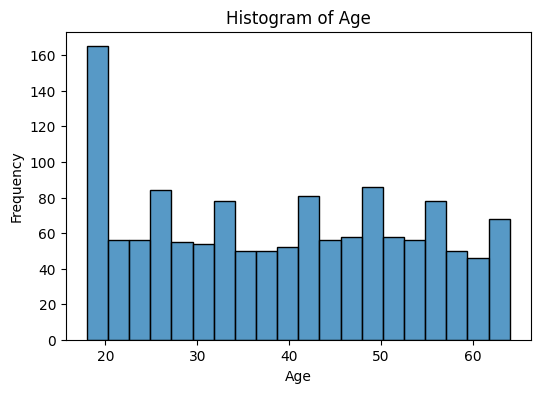

In [43]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=False)
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

KDE plot

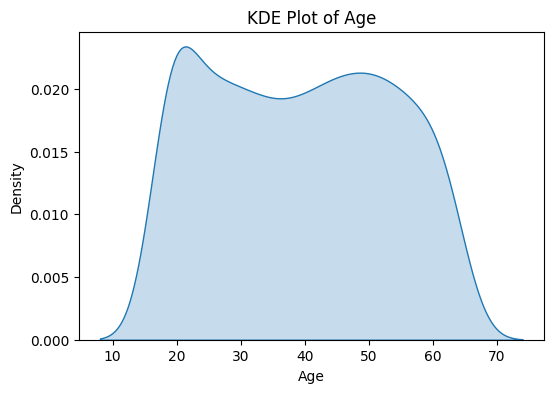

In [44]:
plt.figure(figsize=(6,4))
sns.kdeplot(df['age'], fill=True)
plt.title("KDE Plot of Age")
plt.xlabel("Age")
plt.show()

Box plot

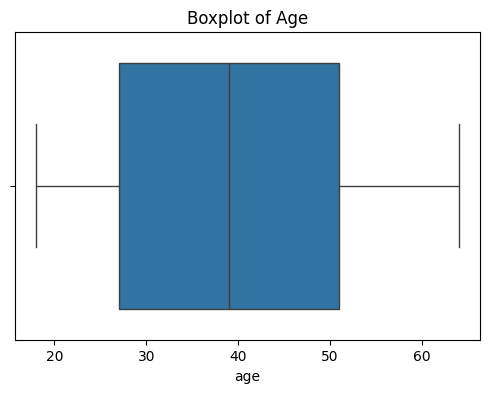

In [45]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title("Boxplot of Age")
plt.show()

# Interpretation
The age variable ranges from young adults to older individuals.
The distribution is fairly uniform.
Few or no significant outliers are visible.

Numerical Feature 2: BMI


Histogram

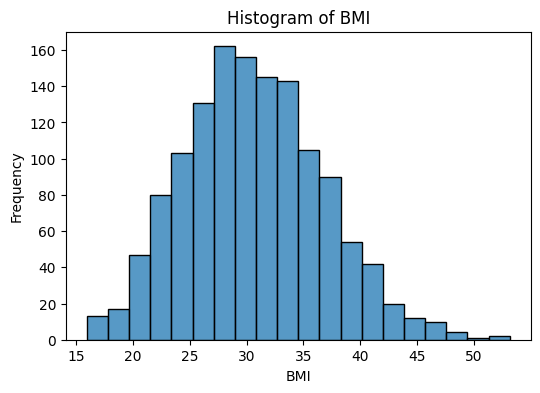

In [46]:
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], bins=20, kde=False)
plt.title("Histogram of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

KDE plot

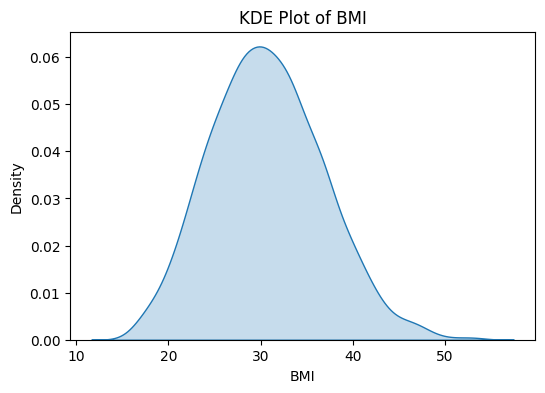

In [47]:
plt.figure(figsize=(6,4))
sns.kdeplot(df['bmi'], fill=True)
plt.title("KDE Plot of BMI")
plt.xlabel("BMI")
plt.show()

Box plot

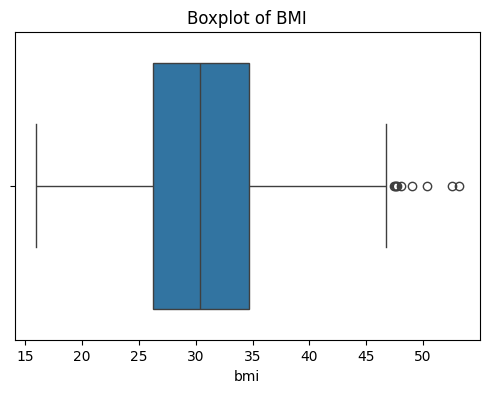

In [49]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['bmi'])
plt.title("Boxplot of BMI")
plt.show()

# Interpretation
BMI is approximately normally distributed.
A few extreme BMI values appear as outliers.
Most individuals have BMI between approximately 25 and 35.

Numerical Feature 3: Children
Histogram

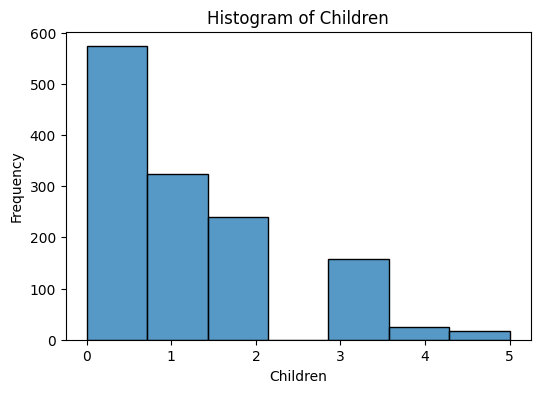

In [50]:
plt.figure(figsize=(6,4))
sns.histplot(df['children'], bins=7, kde=False)
plt.title("Histogram of Children")
plt.xlabel("Children")
plt.ylabel("Frequency")
plt.show()

KDE plot

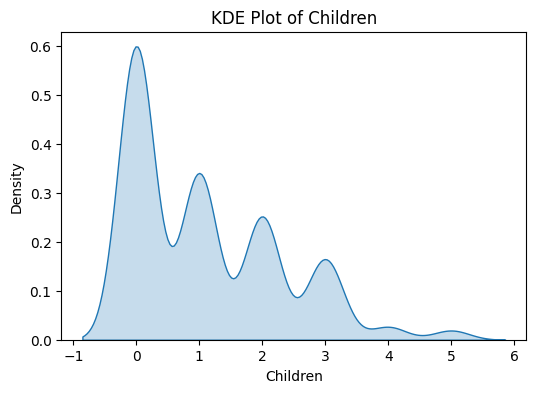

In [51]:
plt.figure(figsize=(6,4))
sns.kdeplot(df['children'], fill=True)
plt.title("KDE Plot of Children")
plt.xlabel("Children")
plt.show()

Box plot

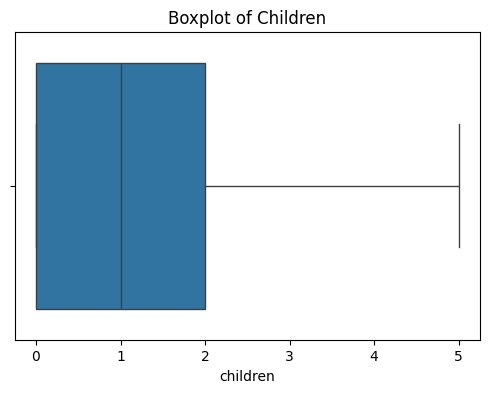

In [53]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['children'])
plt.title("Boxplot of Children")
plt.show()

# Interpretation
Most individuals have 0–2 children.
The distribution is right-skewed.
Higher numbers of children are less frequent

Numerical Feature 4: Charges (Target Variable)

Histogram

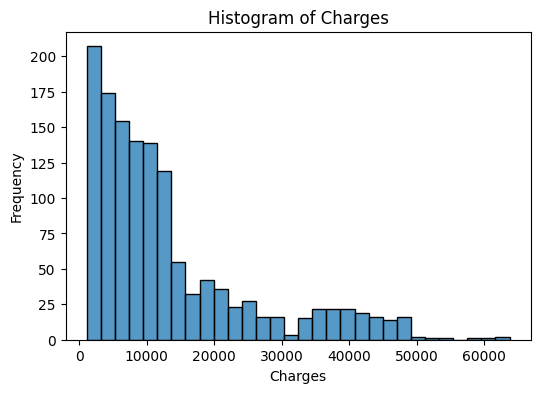

In [57]:
plt.figure(figsize=(6,4))
sns.histplot(df['charges'], bins=30, kde=False)
plt.title("Histogram of Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

KDE plot

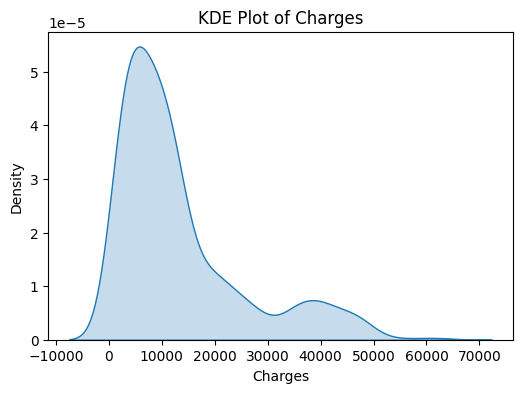

In [56]:
plt.figure(figsize=(6,4))
sns.kdeplot(df['charges'], fill=True)
plt.title("KDE Plot of Charges")
plt.xlabel("Charges")
plt.show()

Box plot

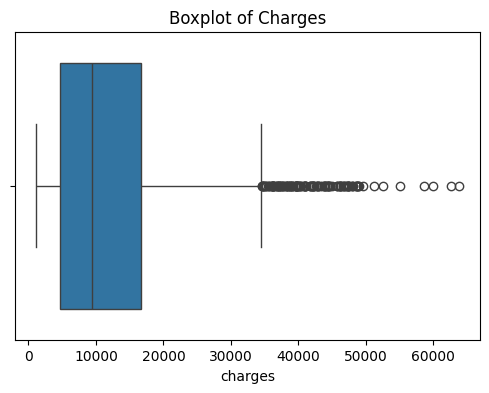

In [54]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['charges'])
plt.title("Boxplot of Charges")
plt.show()

# Interpretation
Medical charges are highly right-skewed.
Most people have relatively low insurance charges.
A number of individuals have extremely high charges, which appear as outliers.

Categorical Features

In [58]:
categorical_features = df.select_dtypes(include='object').columns

categorical_features

Index(['sex', 'smoker', 'region'], dtype='object')

Categorical Feature 1: Sex

Count plot

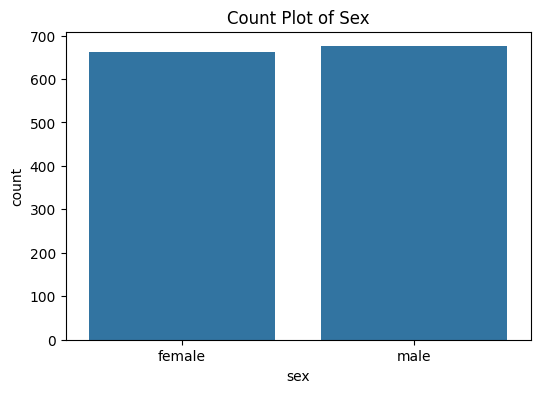

In [59]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=df)
plt.title("Count Plot of Sex")
plt.show()

Value counts

In [60]:
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

# Interpretation
The dataset contains both males and females.
The distribution is nearly balanced.

Categorical Feature 2: Smoker


Count Plot

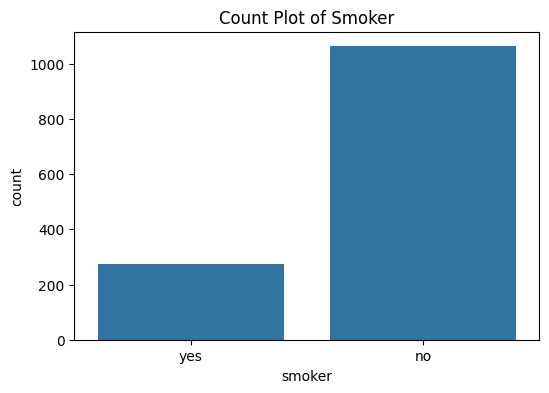

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x='smoker', data=df)
plt.title("Count Plot of Smoker")
plt.show()

Value counts

In [62]:
df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

# Interpretation
Most individuals are non-smokers.
Smokers represent a smaller proportion of the dataset

Categorical Feature 3: Region

Count plot

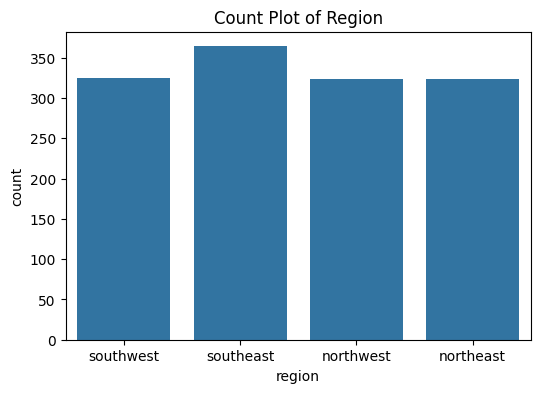

In [63]:
plt.figure(figsize=(6,4))
sns.countplot(x='region', data=df)
plt.title("Count Plot of Region")
plt.show()

Value counts

In [64]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

# Interpretation
Individuals are distributed across four regions.
The number of observations is relatively balanced among the regions

# Bivariate Analysis

Scatter plot with target

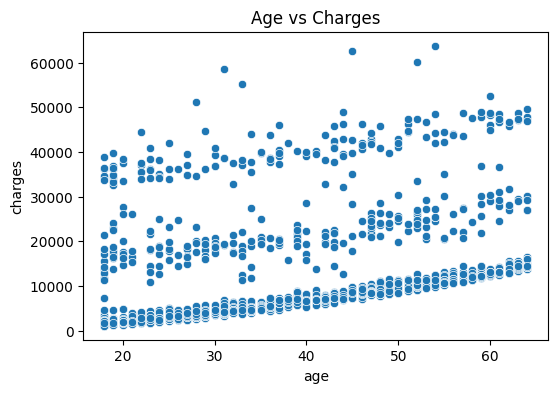

In [65]:
# Scatter Plot: Age vs Charges
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

Age vs Charges: Charges generally increase with age, though there is considerable variability.

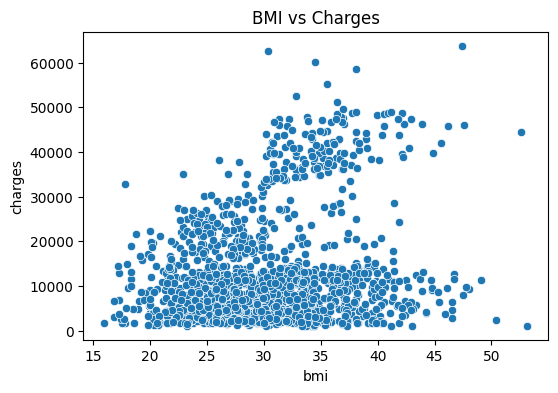

In [66]:
# Scatter Plot: BMI vs Charges
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

BMI vs Charges: Higher BMI values tend to be associated with higher charges, especially among some individuals

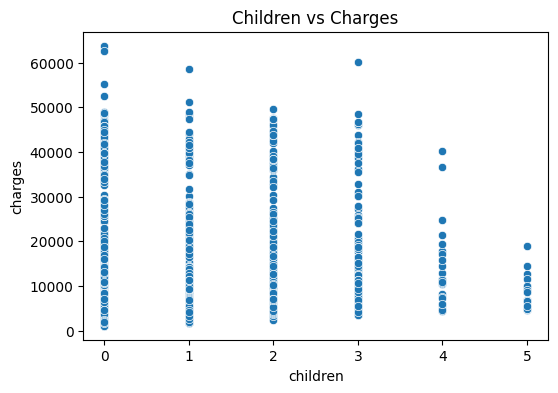

In [68]:
# Scatter Plot: Children vs Charges
plt.figure(figsize=(6,4))
sns.scatterplot(x='children', y='charges', data=df)
plt.title("Children vs Charges")
plt.show()

Children vs Charges: The number of children has a weak positive relationship with charges.

Correlation heatmap

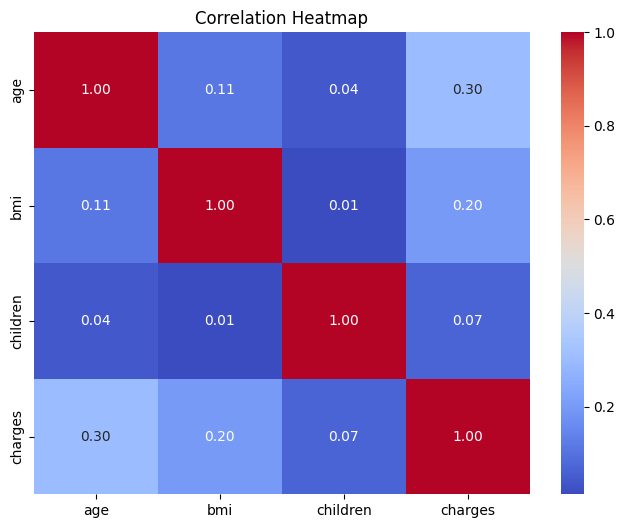

In [69]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

Correlation Heatmap: charges shows the strongest correlation with age among the numerical features, while children has a relatively weak correlation.

Pairplot (selected features)

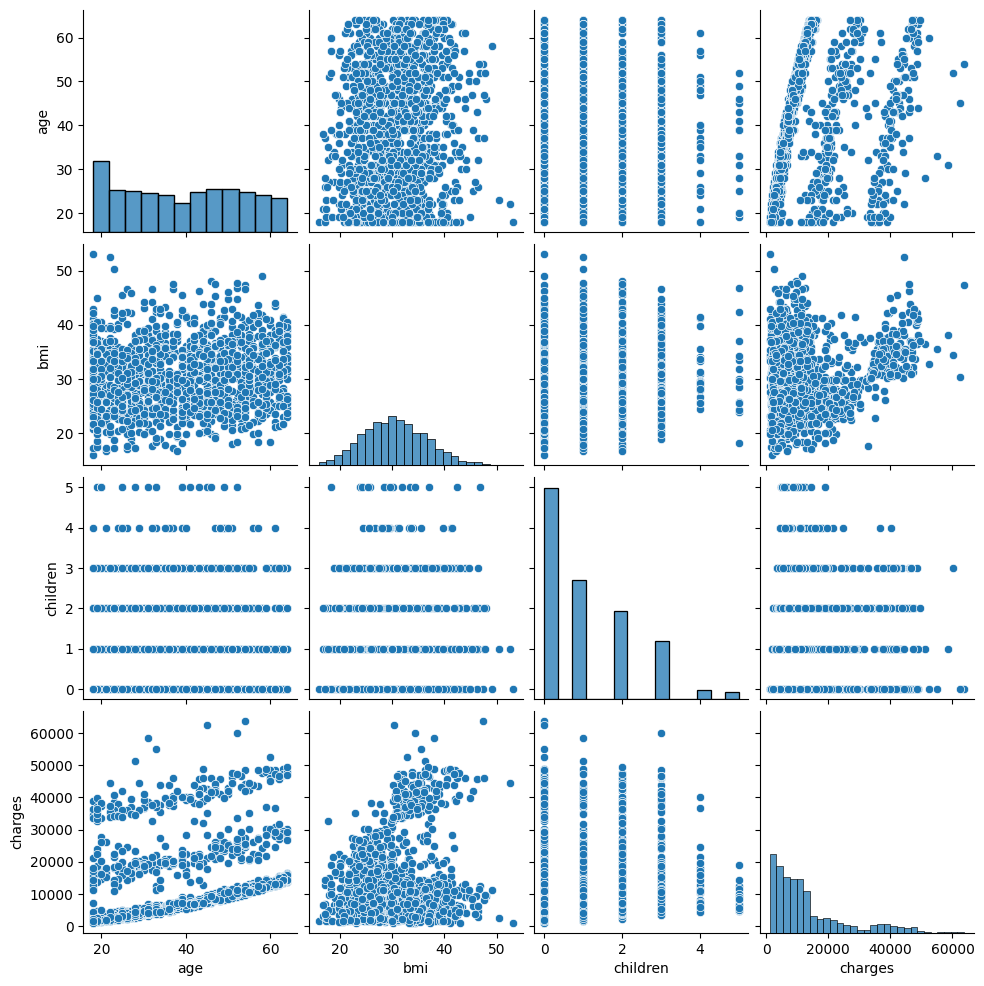

In [70]:
sns.pairplot(df[['age', 'bmi', 'children', 'charges']])

plt.show()

Pairplot: The pairplot helps visualize distributions and pairwise relationships, confirming that charges is right-skewed and has moderate relationships with age and bmi.

# Part 4 — Outlier Detection

In [71]:
from scipy.stats import zscore

In [73]:
# Numerical Features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

numerical_features

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

Method 1 — Boxplots

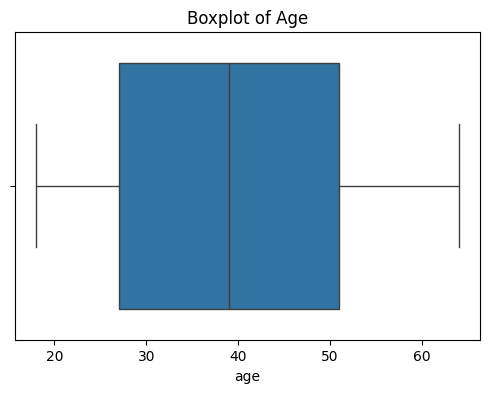

In [74]:
# Age
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title("Boxplot of Age")
plt.show()

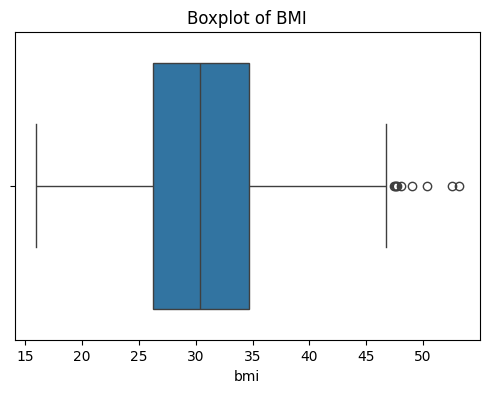

In [75]:
# BMI
plt.figure(figsize=(6,4))
sns.boxplot(x=df['bmi'])
plt.title("Boxplot of BMI")
plt.show()

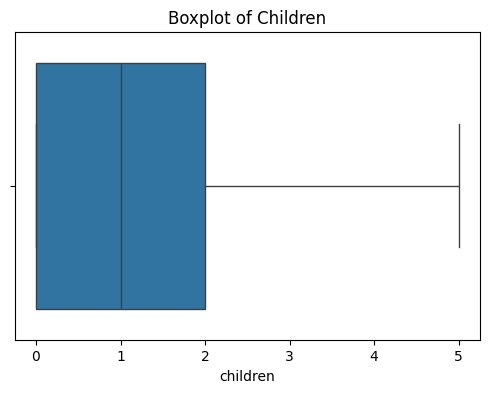

In [77]:
# Children
plt.figure(figsize=(6,4))
sns.boxplot(x=df['children'])
plt.title("Boxplot of Children")
plt.show()

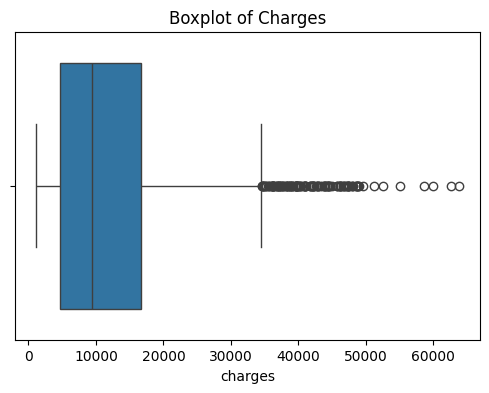

In [78]:
# Charges
plt.figure(figsize=(6,4))
sns.boxplot(x=df['charges'])
plt.title("Boxplot of Charges")
plt.show()

Method 2 — IQR Method

In [83]:
def detect_outliers_iqr(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower) | (data[column] > upper)]

    print(f"{column}")
    print("Number of Outliers:", outliers.shape[0])
    print("----------------------------")
# Detect Outliers in Every Numerical Feature
for col in numerical_features:
    detect_outliers_iqr(df, col)

age
Number of Outliers: 0
----------------------------
bmi
Number of Outliers: 9
----------------------------
children
Number of Outliers: 0
----------------------------
charges
Number of Outliers: 139
----------------------------


Method 3 — Z-Score Method

In [82]:
def detect_outliers_zscore(data, column):

    z_scores = zscore(data[column])

    outliers = data[np.abs(z_scores) > 3]

    print(column)
    print("Number of Outliers:", outliers.shape[0])
    print("----------------------------")
# Detect Outliers in Every Numerical Feature
for col in numerical_features:
    detect_outliers_zscore(df, col)

age
Number of Outliers: 0
----------------------------
bmi
Number of Outliers: 4
----------------------------
children
Number of Outliers: 18
----------------------------
charges
Number of Outliers: 7
----------------------------


Should We Remove Outliers?

For this dataset, No.

# Justification

Medical insurance costs naturally vary among individuals.

Very high medical charges represent genuine patients with expensive treatments, not data entry mistakes.

Similarly, extreme BMI values may represent real individuals.

Removing these observations could reduce the model's ability to learn real-world patterns.

Therefore, the outliers were retained in the dataset.

# Part 5 — Feature Engineering

Identify Categorical Columns

In [84]:
categorical_features = df.select_dtypes(include='object').columns

print(categorical_features)

Index(['sex', 'smoker', 'region'], dtype='object')


In [86]:
# Label Encoding
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

In [87]:
# Create a copy of dataset
df_label = df.copy()

In [89]:
# Encode Binary Categorical Columns
le = LabelEncoder()

df_label['sex'] = le.fit_transform(df_label['sex'])

df_label['smoker'] = le.fit_transform(df_label['smoker'])
df_label.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


Why Label Encoding?

sex has only two categories (male and female).
smoker has only two categories (yes and no).
Since these are binary variables, Label Encoding is sufficient and does not unnecessarily increase the number of features.

In [90]:
# One-Hot Encoding
df_encoded = pd.get_dummies(df_label,
                            columns=['region'],
                            drop_first=True)

df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [91]:
# Display new columns
df_encoded.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

Why One-Hot Encoding?

region has four categories.
There is no natural order among the regions.
One-Hot Encoding converts each category into a separate binary feature without introducing a false numerical relationship.
drop_first=True is used to avoid the Dummy Variable Trap (multicollinearity).

Feature Scaling

In [92]:
# Separate Features and Target
X = df_encoded.drop('charges', axis=1)

y = df_encoded['charges']

In [93]:
# StandardScaler

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

In [94]:
# Create Scaled Features

standard_scaler = StandardScaler()

X_standard = standard_scaler.fit_transform(X)

In [95]:
# Convert to DataFrame

X_standard = pd.DataFrame(X_standard,
                          columns=X.columns)

X_standard.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,-1.440418,-1.009771,-0.453160,-0.909234,1.969660,-0.565546,-0.611638,1.764609
1,-1.511647,0.990324,0.509422,-0.079442,-0.507702,-0.565546,1.634955,-0.566698
2,-0.799350,0.990324,0.383155,1.580143,-0.507702,-0.565546,1.634955,-0.566698
3,-0.443201,0.990324,-1.305052,-0.909234,-0.507702,1.768203,-0.611638,-0.566698
4,-0.514431,0.990324,-0.292456,-0.909234,-0.507702,1.768203,-0.611638,-0.566698


In [96]:
# MinMaxScaler
# Import MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

In [97]:
# Scale Features

minmax_scaler = MinMaxScaler()

X_minmax = minmax_scaler.fit_transform(X)

In [98]:
# Convert to DataFrame

X_minmax = pd.DataFrame(X_minmax,
                        columns=X.columns)

X_minmax.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,0.021739,0.0,0.321227,0.0,1.0,0.0,0.0,1.0
1,0.000000,1.0,0.479150,0.2,0.0,0.0,1.0,0.0
2,0.217391,1.0,0.458434,0.6,0.0,0.0,1.0,0.0
3,0.326087,1.0,0.181464,0.0,0.0,1.0,0.0,0.0
4,0.304348,1.0,0.347592,0.0,0.0,1.0,0.0,0.0


Why Scaling is Required?

Feature scaling transforms numerical variables to a similar scale. It prevents features with large values from dominating those with smaller values, resulting in faster training and better model performance.

Models That Require Scaling

Linear Regression
Polynomial Regression
Logistic Regression
Support Vector Machine (SVM)
K-Nearest Neighbors (KNN)
Neural Networks

Models That Do NOT Require Scaling

Decision Tree
Random Forest
XGBoost
LightGBM
CatBoost

Tree-based models split data based on feature values rather than distances, so scaling is generally unnecessary.

Feature Selection

In [99]:
# Method 1 — Correlation
correlation = df_encoded.corr(numeric_only=True)

correlation

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
age,1.000000,-0.019814,0.109344,0.041536,-0.025587,0.298308,0.001495,-0.012311,0.009415
sex,-0.019814,1.000000,0.046397,0.017848,0.076596,0.058044,-0.012482,0.017578,-0.003767
bmi,0.109344,0.046397,1.000000,0.012755,0.003746,0.198401,-0.136138,0.270057,-0.006211
children,0.041536,0.017848,0.012755,1.000000,0.007331,0.067389,0.026044,-0.023492,0.021538
smoker,-0.025587,0.076596,0.003746,0.007331,1.000000,0.787234,-0.036321,0.068282,-0.037168
charges,0.298308,0.058044,0.198401,0.067389,0.787234,1.000000,-0.038695,0.073578,-0.043637
region_northwest,0.001495,-0.012482,-0.136138,0.026044,-0.036321,-0.038695,1.000000,-0.345909,-0.320493
region_southeast,-0.012311,0.017578,0.270057,-0.023492,0.068282,0.073578,-0.345909,1.000000,-0.346614
region_southwest,0.009415,-0.003767,-0.006211,0.021538,-0.037168,-0.043637,-0.320493,-0.346614,1.000000


In [100]:
# Correlation with Target
correlation['charges'].sort_values(ascending=False)

charges             1.000000
smoker              0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex                 0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64

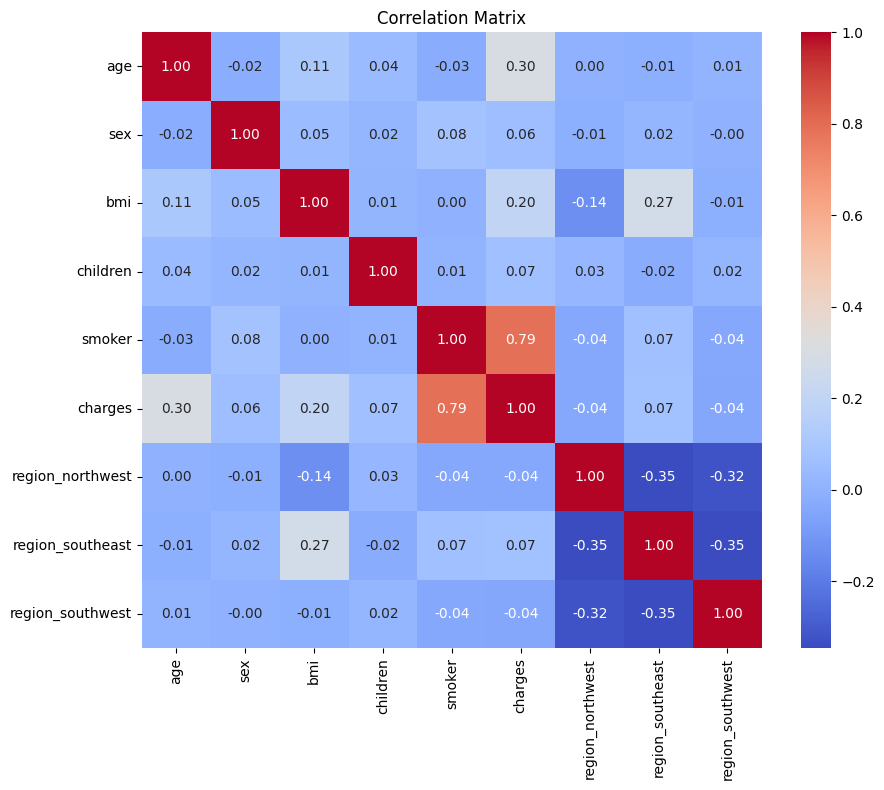

In [101]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

# Interpretation

smoker has the strongest positive correlation with medical charges.
age has a moderate positive correlation.
BMI has a weaker positive correlation.
Children has a weak correlation.
Region features show very little correlation with the target variable.

In [102]:
# Method 2 — PCA (Principal Component Analysis)

# Import PCA

from sklearn.decomposition import PCA

In [103]:
# Apply PCA

pca = PCA()

pca.fit(X_standard)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [104]:
# Explained Variance Ratio

explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.19216322 0.16583517 0.13704414 0.132862   0.11938031 0.11569408
 0.09775907 0.039262  ]


In [105]:
# Cumulative Explained Variance
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.19216322 0.35799838 0.49504252 0.62790453 0.74728484 0.86297892
 0.960738   1.        ]


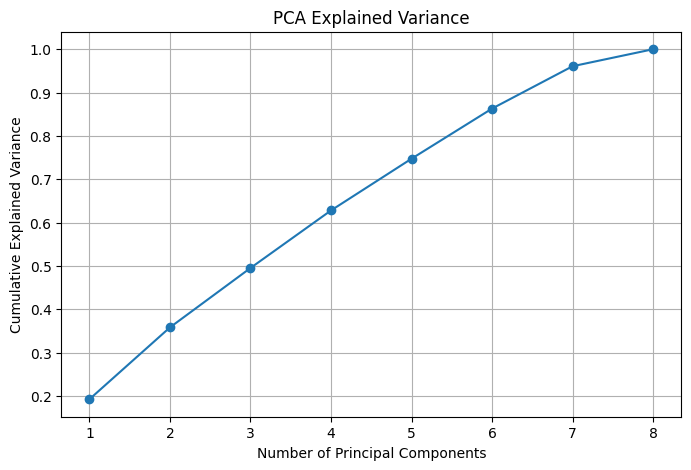

In [106]:
# Plot Explained Variance
plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_variance)+1),
         cumulative_variance,
         marker='o')

plt.xlabel("Number of Principal Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [107]:
# Select Components Explaining 95% Variance
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_standard)

print("Original Shape:", X_standard.shape)

print("Reduced Shape:", X_pca.shape)

Original Shape: (1337, 8)
Reduced Shape: (1337, 7)


Compare Selected Features

Correlation Method

Correlation identifies features that have a strong linear relationship with the target variable. In this dataset, smoker, age, and BMI are the most important predictors of insurance charges.

PCA Method

PCA transforms the original features into a smaller set of principal components while retaining most of the information (95% of the variance). Unlike correlation, PCA creates new composite features rather than selecting existing ones.

# Part 6 — Train-Test Split

This assignment asks for Feature Scaling, but Decision Tree does not require scaling. Since Linear Regression and Polynomial Regression benefit from scaling, we'll use the StandardScaler data (X_standard) that we created in Part 5.

In [108]:
# Import Train-Test Split
from sklearn.model_selection import train_test_split

In [109]:
# Split the Dataset (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_standard,
    y,
    test_size=0.20,
    random_state=42
)

In [110]:
# Display Training and Testing Shapes
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (1069, 8)
X_test Shape  : (268, 8)
y_train Shape : (1069,)
y_test Shape  : (268,)


# Part 7 — Model Training

Model 1 — Linear Regression

In [111]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

In [112]:
# Train the Model
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [113]:
# Make Predictions
y_pred_linear = linear_model.predict(X_test)

In [114]:
# Display First 5 Predictions
linear_predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_linear
})

linear_predictions.head()

,Actual,Predicted
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657


Model 2 — Polynomial Regression (Degree = 2)

In [115]:
# Import PolynomialFeatures
from sklearn.preprocessing import PolynomialFeatures

In [116]:
# Create Polynomial Features (Degree = 2)
poly2 = PolynomialFeatures(degree=2)

X_poly2 = poly2.fit_transform(X_standard)

In [117]:
# Train-Test Split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_poly2,
    y,
    test_size=0.20,
    random_state=42
)

In [118]:
# Train Linear Regression on Polynomial Features
poly_model2 = LinearRegression()

poly_model2.fit(X_train2, y_train2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [120]:
# Predictions
y_pred_poly2 = poly_model2.predict(X_test2)

In [ ]:
# Display First 5 Predictions
poly2_predictions = pd.DataFrame({
    "Actual": y_test2.values,
    "Predicted": y_pred_poly2
})

poly2_predictions.head()

,Actual,Predicted
0,8688.85885,8353.843089
1,5708.86700,6542.119190
2,11436.73815,14316.736746
3,38746.35510,35908.934065
4,4463.20510,5652.797364


Model 3 — Polynomial Regression (Degree = 3)

In [123]:
# Create Polynomial Features
poly3 = PolynomialFeatures(degree=3)

X_poly3 = poly3.fit_transform(X_standard)

In [124]:
# Train-Test Split
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_poly3,
    y,
    test_size=0.20,
    random_state=42
)

In [125]:
# Train Model
poly_model3 = LinearRegression()

poly_model3.fit(X_train3, y_train3)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [126]:
# Make Predictions
y_pred_poly3 = poly_model3.predict(X_test3)
# Display First 5 Predictions
poly3_predictions = pd.DataFrame({
    "Actual": y_test3.values,
    "Predicted": y_pred_poly3
})

poly3_predictions.head()

,Actual,Predicted
0,8688.85885,9601.979992
1,5708.86700,4797.603672
2,11436.73815,13583.883653
3,38746.35510,35227.727294
4,4463.20510,6230.109399


Compare Degree 2 and Degree 3
 Usually:
Degree = 2 captures non-linear relationships without becoming too complex.
Degree = 3 is more flexible but may overfit the training data.

Model 4 — Decision Tree Regressor

In [127]:
# Import Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
# Train the Model
decision_tree = DecisionTreeRegressor(random_state=42)

decision_tree.fit(X_train, y_train)
# Make Predictions
y_pred_tree = decision_tree.predict(X_test)
# Display First 5 Predictions
tree_predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_tree
})

tree_predictions.head()

,Actual,Predicted
0,8688.85885,9361.32680
1,5708.86700,4877.98105
2,11436.73815,10848.13430
3,38746.35510,44585.45587
4,4463.20510,4673.39220


# Part 8 — Model Evaluation (Regression)

In [130]:
# Import Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [131]:
# Evaluate Linear Regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R2 Score:", r2_linear)

Linear Regression
MAE : 4177.045561036322
MSE : 35478020.675235584
RMSE: 5956.342894363586
R2 Score: 0.8069287081198013


In [132]:
# Evaluate Polynomial Regression (Degree = 2)
mae_poly2 = mean_absolute_error(y_test2, y_pred_poly2)
mse_poly2 = mean_squared_error(y_test2, y_pred_poly2)
rmse_poly2 = np.sqrt(mse_poly2)
r2_poly2 = r2_score(y_test2, y_pred_poly2)

print("Polynomial Regression (Degree = 2)")
print("MAE :", mae_poly2)
print("MSE :", mse_poly2)
print("RMSE:", rmse_poly2)
print("R2 Score:", r2_poly2)

Polynomial Regression (Degree = 2)
MAE : 2867.31743947529
MSE : 21585843.72442195
RMSE: 4646.056793068929
R2 Score: 0.8825298972468523


In [133]:
# Evaluate Polynomial Regression (Degree = 3)
mae_poly3 = mean_absolute_error(y_test3, y_pred_poly3)
mse_poly3 = mean_squared_error(y_test3, y_pred_poly3)
rmse_poly3 = np.sqrt(mse_poly3)
r2_poly3 = r2_score(y_test3, y_pred_poly3)

print("Polynomial Regression (Degree = 3)")
print("MAE :", mae_poly3)
print("MSE :", mse_poly3)
print("RMSE:", rmse_poly3)
print("R2 Score:", r2_poly3)

Polynomial Regression (Degree = 3)
MAE : 3048.863649153704
MSE : 23719529.852298096
RMSE: 4870.269997884932
R2 Score: 0.8709183831506484


In [134]:
# Evaluate Decision Tree Regressor
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R2 Score:", r2_tree)

Decision Tree Regressor
MAE : 2777.8549919738807
MSE : 34226992.05307391
RMSE: 5850.3839235621035
R2 Score: 0.8137368024740745


In [135]:
# Create Comparison Table
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression (Degree 2)",
        "Polynomial Regression (Degree 3)",
        "Decision Tree Regressor"
    ],
    "MAE": [
        mae_linear,
        mae_poly2,
        mae_poly3,
        mae_tree
    ],
    "MSE": [
        mse_linear,
        mse_poly2,
        mse_poly3,
        mse_tree
    ],
    "RMSE": [
        rmse_linear,
        rmse_poly2,
        rmse_poly3,
        rmse_tree
    ],
    "R2 Score": [
        r2_linear,
        r2_poly2,
        r2_poly3,
        r2_tree
    ]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4177.045561,3.547802e+07,5956.342894,0.806929
1,Polynomial Regression (Degree 2),2867.317439,2.158584e+07,4646.056793,0.882530
2,Polynomial Regression (Degree 3),3048.863649,2.371953e+07,4870.269998,0.870918
3,Decision Tree Regressor,2777.854992,3.422699e+07,5850.383924,0.813737


In [136]:
# Best Model
best_model = comparison.loc[comparison["R2 Score"].idxmax()]

print(best_model)

Model       Polynomial Regression (Degree 2)
MAE                              2867.317439
MSE                          21585843.724422
RMSE                             4646.056793
R2 Score                             0.88253
Name: 1, dtype: object


Interpretation

Lower MAE, MSE, and RMSE indicate better prediction accuracy.
A higher R² Score indicates that the model explains a greater proportion of the variance in the target variable.
The model with the highest R² score and the lowest error values is considered the best-performing regression model.